In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import check_grad

## Create class NeuralNetwork to use

In [33]:
class NeuralNetwork:
    """
    Neural Network for XOR problem
    Architecture: Input -> Hidden -> Output
    Activation: Sigmoid for both hidden and output layers
    Loss: Mean Squared Error (MSE)
    """
    
    def __init__(self, input_size=2, hidden_size=2, output_size=1, seed=42):
        np.random.seed(seed)
        
        # Xavier/Glorot initialization
        limit_hidden = np.sqrt(6 / (input_size + hidden_size))
        self.W1 = np.random.uniform(-limit_hidden, limit_hidden, (input_size, hidden_size))
        self.b1 = np.zeros(hidden_size)
        
        limit_output = np.sqrt(6 / (hidden_size + output_size))
        self.W2 = np.random.uniform(-limit_output, limit_output, (hidden_size, output_size))
        self.b2 = np.zeros(output_size)
        
        # Store intermediate values for backprop
        self.cache = {}
    
    def sigmoid(self, x):
        """Sigmoid activation function"""
        x = np.clip(x, -500, 500)
        return 1.0 / (1.0 + np.exp(-x))
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid: σ(x) * (1 - σ(x))"""
        sx = self.sigmoid(x)
        return sx * (1 - sx)
    
    def forward(self, X):
        """
        Forward pass
        X: input of shape (batch_size, input_size)
        Returns: output of shape (batch_size, output_size)
        """
        # Hidden layer
        z1 = np.dot(X, self.W1) + self.b1  # Linear transformation
        a1 = self.sigmoid(z1)               # Activation
        
        # Output layer
        z2 = np.dot(a1, self.W2) + self.b2  # Linear transformation
        a2 = self.sigmoid(z2)               # Activation
        
        # Cache for backpropagation
        self.cache = {'X': X, 'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2}
        
        return a2
    
    def compute_loss(self, y_pred, y_true):
        """Mean Squared Error loss"""
        return np.mean((y_pred - y_true) ** 2)
    
    def backward(self, y_true):
        """
        Manual backpropagation using chain rule
        y_true: true labels of shape (batch_size, output_size)
        Returns: gradients for W1, b1, W2, b2
        """
        batch_size = len(y_true)
        
        # Unpack cached values
        X = self.cache['X']
        a1 = self.cache['a1']
        z2 = self.cache['z2']
        a2 = self.cache['a2']
        
        # ===== Output layer gradients =====
        dL_da2 = 2 * (a2 - y_true) / batch_size
        
        da2_dz2 = self.sigmoid_derivative(z2)
        
        dL_dz2 = dL_da2 * da2_dz2
        
        # Gradients for output layer
        dW2 = np.dot(a1.T, dL_dz2)
        db2 = np.sum(dL_dz2, axis=0, keepdims=True).flatten()
        
        # ===== Hidden layer gradients =====
        dL_da1 = np.dot(dL_dz2, self.W2.T)
        
        da1_dz1 = self.sigmoid_derivative(self.cache['z1'])
        
        dL_dz1 = dL_da1 * da1_dz1
        
        # Gradients for hidden layer
        dW1 = np.dot(X.T, dL_dz1)
        db1 = np.sum(dL_dz1, axis=0, keepdims=True).flatten()
        
        return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}
    
    def update_parameters(self, gradients, learning_rate):
        """Update parameters using gradient descent"""
        self.W1 -= learning_rate * gradients['W1']
        self.b1 -= learning_rate * gradients['b1']
        self.W2 -= learning_rate * gradients['W2']
        self.b2 -= learning_rate * gradients['b2']
    
    def train_step(self, X, y_true, learning_rate):
        """Single training step: forward, backward, update"""
        y_pred = self.forward(X)
        loss = self.compute_loss(y_pred, y_true)
        gradients = self.backward(y_true)
        self.update_parameters(gradients, learning_rate)
        return loss
    
    def predict(self, X):
        """Make predictions (returns probabilities)"""
        return self.forward(X)
    
    def predict_binary(self, X):
        """Make binary predictions (0 or 1)"""
        return np.round(self.predict(X))
    
    def get_parameters(self):
        """Return all parameters as a flat array (for gradient checking)"""
        return np.concatenate([self.W1.flatten(), self.b1.flatten(), 
                                self.W2.flatten(), self.b2.flatten()])
    
    def set_parameters(self, params):
        """Set parameters from a flat array"""
        w1_size = self.W1.size
        b1_size = self.b1.size
        w2_size = self.W2.size
        b2_size = self.b2.size
        
        idx = 0
        self.W1 = params[idx:idx+w1_size].reshape(self.W1.shape)
        idx += w1_size
        self.b1 = params[idx:idx+b1_size].reshape(self.b1.shape)
        idx += b1_size
        self.W2 = params[idx:idx+w2_size].reshape(self.W2.shape)
        idx += w2_size
        self.b2 = params[idx:idx+b2_size].reshape(self.b2.shape)

## Define functions to verify the gradient descent

In [34]:
def compute_loss_numerical(nn, X, y, params):
    """Compute loss for given parameters (for gradient checking)"""
    nn.set_parameters(params)
    y_pred = nn.forward(X)
    return nn.compute_loss(y_pred, y)

def compute_gradients_manual(nn, X, y):
    """Compute gradients manually using backpropagation"""
    y_pred = nn.forward(X)
    loss = nn.compute_loss(y_pred, y)
    gradients = nn.backward(y)
    
    return np.concatenate([gradients['W1'].flatten(), gradients['b1'].flatten(),
                          gradients['W2'].flatten(), gradients['b2'].flatten()])

def verify_gradients():
    """Verify manual gradients using scipy's check_grad (numerical differentiation)"""
    print("\n" + "="*60)
    print("GRADIENT VERIFICATION")
    print("="*60)
    
    nn_test = NeuralNetwork(input_size=2, hidden_size=2, output_size=1, seed=42)
    X_test = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_test = np.array([[0], [1], [1], [0]])
    
    params0 = nn_test.get_parameters()
    
    def loss_func(params):
        nn_test.set_parameters(params)
        y_pred = nn_test.forward(X_test)
        return nn_test.compute_loss(y_pred, y_test)
    
    grad_manual = compute_gradients_manual(nn_test, X_test, y_test)
    
    # Use scipy's check_grad for numerical verification
    err = check_grad(loss_func, lambda params: compute_gradients_manual(nn_test, X_test, y_test), params0)
    
    print(f"Gradient verification error (should be < 1e-5): {err:.2e}")
    
    if err < 1e-5:
        print("✓ Gradients are correct!")
    else:
        print("✗ Gradient mismatch detected!")
    
    # Additional manual numerical gradient check for first few parameters
    print("\nDetailed gradient check (first 10 parameters):")
    print(f"{'Param':^8} {'Manual Grad':^15} {'Numerical Grad':^15} {'Difference':^15}")
    print("-"*60)
    
    eps = 1e-6
    for i in range(min(10, len(params0))):
        params_plus = params0.copy()
        params_minus = params0.copy()
        params_plus[i] += eps
        params_minus[i] -= eps
        
        loss_plus = loss_func(params_plus)
        loss_minus = loss_func(params_minus)
        grad_numerical = (loss_plus - loss_minus) / (2 * eps)
        
        print(f"{i:^8} {grad_manual[i]:^15.6e} {grad_numerical:^15.6e} {abs(grad_manual[i]-grad_numerical):^15.2e}")
    
    return err

## Define functions to train the network

In [35]:
def train_xor_network():
    """Train the neural network on XOR problem"""
    
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])
    
    nn = NeuralNetwork(input_size=2, hidden_size=2, output_size=1, seed=42)
    
    epochs = 5000
    learning_rate = 0.5
    loss_history = []
    
    print("\n" + "="*60)
    print("TRAINING NEURAL NETWORK ON XOR PROBLEM")
    print("="*60)
    print(f"Architecture: 2-2-1 (2 inputs, 2 hidden, 1 output)")
    print(f"Activation: Sigmoid (hidden and output)")
    print(f"Loss: Mean Squared Error (MSE)")
    print(f"Learning rate: {learning_rate}")
    print(f"Epochs: {epochs}")
    print("-"*60)
    
    for epoch in range(epochs):
        loss = nn.train_step(X, y, learning_rate)
        loss_history.append(loss)
        
        # Print progress every 500 epochs
        if epoch % 500 == 0:
            y_pred = nn.predict(X)
            y_binary = nn.predict_binary(X)
            accuracy = np.mean(y_binary.flatten() == y.flatten()) * 100
            print(f"Epoch {epoch:4d}: Loss = {loss:.6f}, Accuracy = {accuracy:.1f}%")
    
    print("-"*60)
    print("Training completed!")
    
    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    
    y_pred = nn.predict(X)
    y_binary = nn.predict_binary(X)
    
    print("\nPredictions:")
    print(f"{'Input':^12} {'True':^8} {'Predicted':^12} {'Binary':^8} {'Correct':^8}")
    print("-"*60)
    
    correct = 0
    for i in range(len(X)):
        is_correct = y_binary[i, 0] == y[i, 0]
        correct += is_correct
        status = "✓" if is_correct else "✗"
        print(f"({X[i,0]},{X[i,1]}){'':^4} {y[i,0]:^8} {y_pred[i,0]:^12.6f} {y_binary[i,0]:^8} {status:^8}")
    
    accuracy = correct / len(X) * 100
    print("-"*60)
    print(f"\nFinal Accuracy: {accuracy:.1f}% ({correct}/{len(X)})")
    print(f"Final Loss: {loss_history[-1]:.6f}")
    
    return nn, loss_history, X, y

## Define functions to visualize the process and results

In [36]:
def plot_training_process(loss_history):
    """Plot the training convergence"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(loss_history, 'b-', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('MSE Loss', fontsize=12)
    axes[0].set_title('Training Convergence (Linear Scale)', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, len(loss_history))
    
    axes[1].semilogy(loss_history, 'r-', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MSE Loss (log scale)', fontsize=12)
    axes[1].set_title('Training Convergence (Semi-log Scale)', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, len(loss_history))
    
    plt.tight_layout()
    # plt.savefig('training_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_3d_surface(nn, X_train, y_train):
    """Create 3D surface plot of the learned XOR function"""
    
    resolution = 50
    x1_grid = np.linspace(-0.2, 1.2, resolution)
    x2_grid = np.linspace(-0.2, 1.2, resolution)
    X1, X2 = np.meshgrid(x1_grid, x2_grid)
    
    Z = np.zeros_like(X1)
    for i in range(resolution):
        for j in range(resolution):
            X_input = np.array([[X1[i, j], X2[i, j]]])
            Z[i, j] = nn.predict(X_input)[0, 0]
    
    fig = plt.figure(figsize=(15, 5))
    
    # 1. 3D Surface plot
    ax1 = fig.add_subplot(131, projection='3d')
    surf = ax1.plot_surface(X1, X2, Z, cmap='coolwarm', alpha=0.8, linewidth=0, antialiased=True)
    ax1.scatter(X_train[:, 0], X_train[:, 1], y_train.flatten(), 
                color='black', s=100, edgecolor='white', linewidth=2, 
                label='Training Data', zorder=5)
    ax1.set_xlabel('x1', fontsize=10)
    ax1.set_ylabel('x2', fontsize=10)
    ax1.set_zlabel('Network Output', fontsize=10)
    ax1.set_title('Learned XOR Function (3D Surface)', fontsize=12)
    ax1.legend()
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='Output')
    
    # 2. Contour plot with decision boundary
    ax2 = fig.add_subplot(132)
    contour = ax2.contourf(X1, X2, Z, levels=20, cmap='coolwarm', alpha=0.8)
    ax2.contour(X1, X2, Z, levels=[0.5], colors='black', linewidths=2, linestyles='-')
    ax2.scatter(X_train[:, 0], X_train[:, 1], c=y_train.flatten(), 
                cmap='coolwarm', s=100, edgecolor='black', linewidth=2, 
                vmin=0, vmax=1, zorder=5)
    
    for i, (x1, x2) in enumerate(X_train):
        ax2.annotate(f'({x1},{x2})', (x1, x2), xytext=(5, 5), 
                    textcoords='offset points', fontsize=9, fontweight='bold')
    
    ax2.set_xlabel('x1', fontsize=10)
    ax2.set_ylabel('x2', fontsize=10)
    ax2.set_title('Decision Boundary (Contour Plot)', fontsize=12)
    ax2.set_xlim(-0.1, 1.1)
    ax2.set_ylim(-0.1, 1.1)
    fig.colorbar(contour, ax=ax2, label='Network Output')
    
    # 3. Cross-section along diagonal
    ax3 = fig.add_subplot(133)
    diag_values = np.linspace(-0.2, 1.2, 100)
    outputs_diag = []
    for d in diag_values:
        X_input = np.array([[d, d]])
        outputs_diag.append(nn.predict(X_input)[0, 0])
    
    ax3.plot(diag_values, outputs_diag, 'b-', linewidth=2, label='f(x,x)')
    ax3.axhline(y=0.5, color='r', linestyle='--', label='Decision boundary (0.5)')
    
    # Mark training points on diagonal
    for x in [0, 1]:
        ax3.axvline(x=x, color='gray', linestyle=':', alpha=0.5)
    
    ax3.set_xlabel('x (where x1 = x2)', fontsize=10)
    ax3.set_ylabel('Network Output', fontsize=10)
    ax3.set_title('Cross-section along diagonal', fontsize=12)
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='best')
    ax3.set_xlim(-0.2, 1.2)
    ax3.set_ylim(-0.1, 1.1)
    
    plt.tight_layout()
    # plt.savefig('xor_3d_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()


def visualize_hidden_neurons(nn, X_train):
    """Visualize what each hidden neuron has learned"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    resolution = 50
    x1_grid = np.linspace(0, 1, resolution)
    x2_grid = np.linspace(0, 1, resolution)
    X1, X2 = np.meshgrid(x1_grid, x2_grid)
    
    for idx, ax in enumerate(axes):
        Z_hidden = np.zeros_like(X1)
        for i in range(resolution):
            for j in range(resolution):
                X_input = np.array([[X1[i, j], X2[i, j]]])
                z1 = np.dot(X_input, nn.W1) + nn.b1
                a1 = nn.sigmoid(z1)
                Z_hidden[i, j] = a1[0, idx]
        
        contour = ax.contourf(X1, X2, Z_hidden, levels=20, cmap='viridis', alpha=0.8)
        ax.scatter(X_train[:, 0], X_train[:, 1], c=['blue', 'red', 'red', 'blue'], 
                  s=80, edgecolor='black', linewidth=2, zorder=5)
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_title(f'Hidden Neuron {idx+1} Activation', fontsize=12)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        fig.colorbar(contour, ax=ax, label='Activation')
    
    plt.tight_layout()
    # plt.savefig('hidden_neurons.png', dpi=150, bbox_inches='tight')
    plt.show()

## Excecution


████████████████████████████████████████████████████████████
STEP 1: Gradient Verification
████████████████████████████████████████████████████████████

GRADIENT VERIFICATION
Gradient verification error (should be < 1e-5): 9.23e-09
✓ Gradients are correct!

Detailed gradient check (first 10 parameters):
 Param     Manual Grad   Numerical Grad    Difference   
------------------------------------------------------------
   0      1.232633e-02    1.232633e-02      1.97e-12    
   1      9.853841e-03    9.853841e-03      1.37e-11    
   2      1.132399e-02    1.132399e-02      1.10e-11    
   3      1.376245e-02    1.376245e-02      4.69e-12    
   4      2.119503e-02    2.119503e-02      1.49e-11    
   5      1.976650e-02    1.976650e-02      1.93e-11    
   6      -4.999473e-02   -4.999473e-02     1.98e-11    
   7      -6.333535e-02   -6.333535e-02     2.49e-11    
   8      -9.374771e-02   -9.374771e-02     1.88e-12    

████████████████████████████████████████████████████████████
S

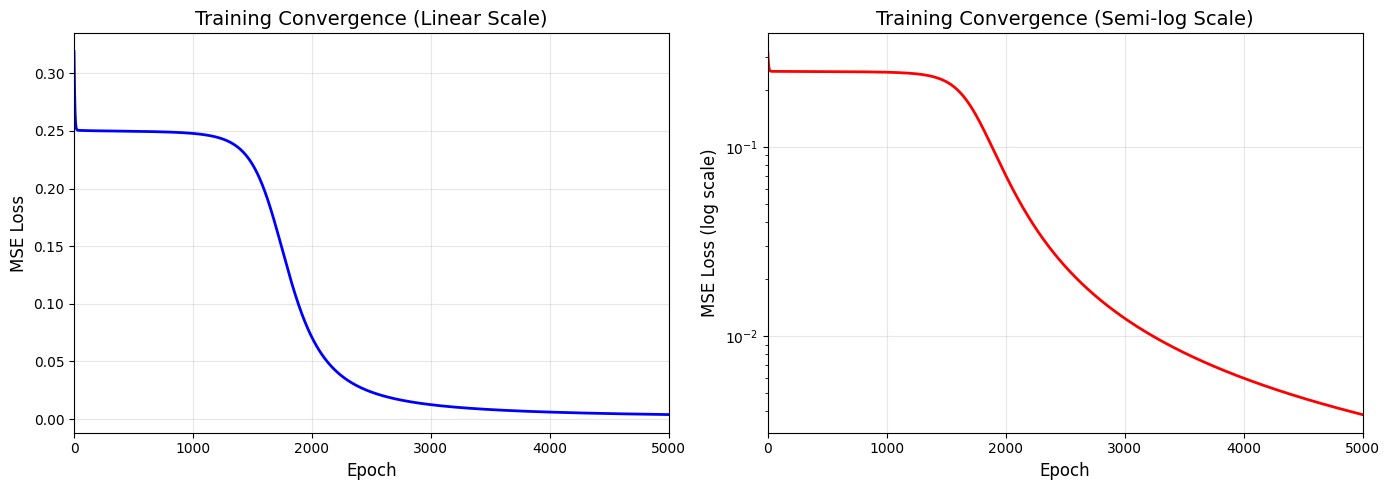


████████████████████████████████████████████████████████████
STEP 4: 3D Surface Plot
████████████████████████████████████████████████████████████


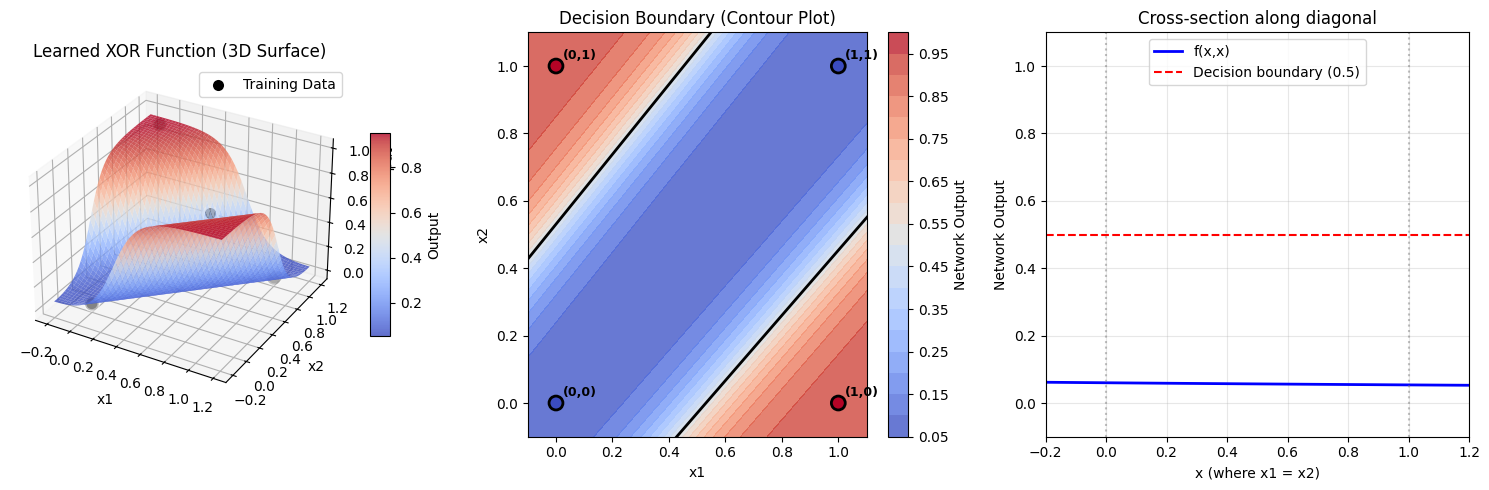


████████████████████████████████████████████████████████████
BONUS: Hidden Neuron Visualization
████████████████████████████████████████████████████████████


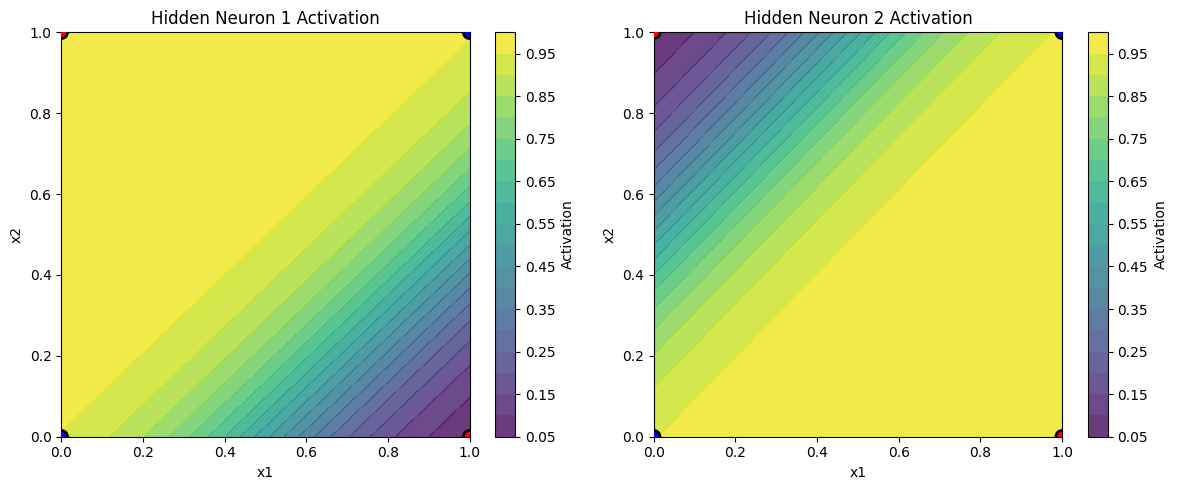


████████████████████████████████████████████████████████████
FINAL NETWORK PARAMETERS
████████████████████████████████████████████████████████████
W1 (input->hidden):
[[-5.62500077  5.87069537]
 [ 5.81712649 -5.66554477]]

b1 (hidden biases):
[2.86817243 2.88600797]

W2 (hidden->output):
[[-6.46045842]
 [-6.45306476]]

b2 (output bias):
[9.47592028]

████████████████████████████████████████████████████████████
FINAL VERIFICATION
████████████████████████████████████████████████████████████
XOR(0,0) = 0.0 (raw: 0.0601)
XOR(0,1) = 1.0 (raw: 0.9334)
XOR(1,0) = 1.0 (raw: 0.9333)
XOR(1,1) = 0.0 (raw: 0.0538)


In [37]:
# Step 1: Verify gradients
print("\n" + "█"*60)
print("STEP 1: Gradient Verification")
print("█"*60)
verify_gradients()

# Step 2: Train the network
print("\n" + "█"*60)
print("STEP 2: Training")
print("█"*60)
nn, loss_history, X_train, y_train = train_xor_network()

# Step 3: Plot training convergence
print("\n" + "█"*60)
print("STEP 3: Training Visualization")
print("█"*60)
plot_training_process(loss_history)

# Step 4: 3D visualization of learned function
print("\n" + "█"*60)
print("STEP 4: 3D Surface Plot")
print("█"*60)
plot_3d_surface(nn, X_train, y_train)

# Bonus: Visualize hidden neurons
print("\n" + "█"*60)
print("BONUS: Hidden Neuron Visualization")
print("█"*60)
visualize_hidden_neurons(nn, X_train)

# Print final network parameters
print("\n" + "█"*60)
print("FINAL NETWORK PARAMETERS")
print("█"*60)
print(f"W1 (input->hidden):\n{nn.W1}")
print(f"\nb1 (hidden biases):\n{nn.b1}")
print(f"\nW2 (hidden->output):\n{nn.W2}")
print(f"\nb2 (output bias):\n{nn.b2}")

# Test on all XOR inputs one more time
print("\n" + "█"*60)
print("FINAL VERIFICATION")
print("█"*60)
for x in [[0, 0], [0, 1], [1, 0], [1, 1]]:
    pred = nn.predict(np.array([x]))
    binary = nn.predict_binary(np.array([x]))
    print(f"XOR({x[0]},{x[1]}) = {binary[0,0]} (raw: {pred[0,0]:.4f})")